In [8]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression 
from sklearn.impute import SimpleImputer
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [3]:
data=pd.read_excel("T:\GOFFOR\Analysis\Ratings Database v20.xls")

<>:1: SyntaxWarning: invalid escape sequence '\G'
<>:1: SyntaxWarning: invalid escape sequence '\G'
C:\Users\kennyynlee\AppData\Local\Temp\ipykernel_31396\3582506388.py:1: SyntaxWarning: invalid escape sequence '\G'
  data=pd.read_excel("T:\GOFFOR\Analysis\Ratings Database v20.xls")


In [4]:
data.tail()

,Date,Race_no,Track,Course,Bend,Distance,Rank,Class_no,Rating_range,Horse_name,...,Trainer,Horse Section Time,Odds1,Dividend,Strength,Rating,Blank,Adj,Base,Position
31702,2025-10-19,10,TURF,ST,C+3,1600,10,3,080-060,WINNING GOLD,...,W. Y. So,24.12 22.60 23.68 23.97,41.0,NaN,NaN,82.416,NaN,0.0,93.666,NaN
31703,2025-10-19,10,TURF,ST,C+3,1600,11,3,080-060,I CAN,...,P. C. Ng,24.48 22.52 23.44 24.25,65.0,NaN,NaN,75.750,NaN,0.0,92.000,NaN
31704,2025-10-19,10,TURF,ST,C+3,1600,12,3,080-060,MORGAN SUCCESS,...,D. J. Whyte,24.24 22.72 23.48 24.76,9.2,NaN,NaN,67.583,NaN,0.0,91.333,NaN
31705,2025-10-19,10,TURF,ST,C+3,1600,13,3,080-060,AWESOME FLUKE,...,P. F. Yiu,24.08 22.40 23.72 25.13,19.0,NaN,NaN,68.375,NaN,0.0,94.000,NaN
31706,2025-10-19,10,TURF,ST,C+3,1600,14,3,080-060,MASTER TRILLION,...,F. C. Lor,25.00 22.68 23.80 24.55,25.0,NaN,NaN,52.458,NaN,0.0,89.333,NaN


In [5]:
X=data[['Weight', 'Draw', 'Margin']]
Y=data['Rank']
imputer=SimpleImputer(strategy='mean')
X_imputed=imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=X.columns)
X_imputed_with_const = sm.add_constant(X_imputed)
                      

In [6]:
model = sm.OLS(Y, X_imputed_with_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rank   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.470
Method:                 Least Squares   F-statistic:                     9375.
Date:                Mon, 20 Oct 2025   Prob (F-statistic):               0.00
Time:                        14:13:26   Log-Likelihood:                -76073.
No. Observations:               31707   AIC:                         1.522e+05
Df Residuals:                   31703   BIC:                         1.522e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.7210      0.319     21.076      0.0

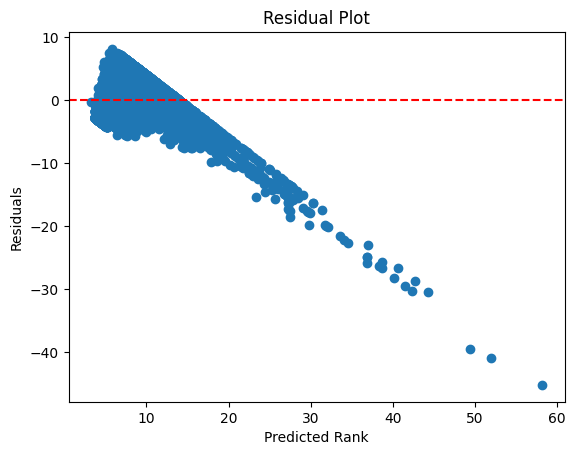

In [9]:
predictions = model.predict(X_imputed_with_const)
residuals = Y - predictions
plt.scatter(predictions, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Rank')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

In [14]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel

# Assuming data is loaded as in the original notebook
# data = pd.read_excel("T:\\GOFFOR\\Analysis\\Ratings Database v20.xls")

# Select features and target
X = data[['Weight', 'Draw', 'Margin']]
Y = data['Rank']

# Impute missing values using mean strategy
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
X_imputed = pd.DataFrame(X_imputed, columns=X.columns)

# Ensure Y is integer for ordinal regression
Y = Y.astype(int)

# Fit ordinal regression model (no constant term added)
model = OrderedModel(Y, X_imputed, distr='logit')
result = model.fit(method='bfgs')  # BFGS optimization for stability

# Print the summary table
print(result.summary())

Optimization terminated successfully.
         Current function value: 2.134397
         Iterations: 54
         Function evaluations: 57
         Gradient evaluations: 57
                             OrderedModel Results                             
Dep. Variable:                   Rank   Log-Likelihood:                -67675.
Model:                   OrderedModel   AIC:                         1.354e+05
Method:            Maximum Likelihood   BIC:                         1.355e+05
Date:                Mon, 20 Oct 2025                                         
Time:                        14:18:59                                         
No. Observations:               31707                                         
Df Residuals:                   31691                                         
Df Model:                           3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

Ordered logistic regression : Weight * -0.0107 + Draw * 0.0477 + Margin *0.5803

 #- If the linear predictor < -2.1323 , the horse is liekly rank 1 


 #- If -2.1323 <Linear Predictor <0.0230 , rank 2 likely